# Natural Language Processing with Disaster Tweets

In [1]:
import numpy as np
import pandas as pd
import os
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from textblob import TextBlob

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [5]:
train.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

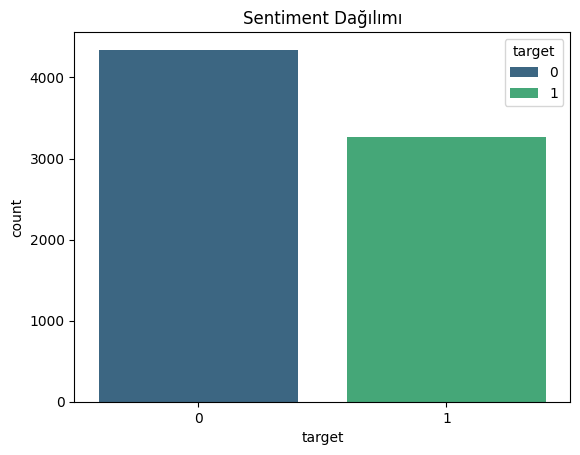

In [6]:
sns.countplot(x=train['target'], hue=train['target'], palette='viridis')
plt.title("Sentiment Dağılımı")
plt.show()

In [7]:
#Cleaning
def clean_text(df, col='text'):
    df[col] = df[col].str.lower()                              # küçük harf
    df[col] = df[col].str.replace('<.*?>', '', regex=True)     # HTML tagları (<br/>)
    df[col] = df[col].str.replace('[^\w\s]', '', regex=True)   # noktalama
    df[col] = df[col].str.replace('\d+', '', regex=True)       # rakamlar
    df[col] = df[col].str.replace('\n', '', regex=True)        # satır sonu
    df[col] = df[col].str.replace('\r', '', regex=True)        # enter
    return df

In [8]:
train = clean_text(train)
test  = clean_text(test)

In [9]:
train['text'][1]

'forest fire near la ronge sask canada'

In [10]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MONSTER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
def ekkok(text):
    words = TextBlob(text).words
    return [word.lemmatize() for word in words if word.lower() not in stop_words]

In [12]:
x_train = train['text']
y_train = train['target']

In [13]:
x_test = test['text']

In [14]:
vect = CountVectorizer(ngram_range=(1, 2), analyzer=ekkok, stop_words='english')
x_train = vect.fit_transform(x_train)
x_test  = vect.transform(x_test)

In [15]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,test_size=0.2,random_state=42,stratify=y_train  )

In [16]:
ml_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, C=1.0),
    'LinearSVC'           : LinearSVC(max_iter=1000),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
}

ml_results = {}

for name, m in ml_models.items():
    m.fit(x_train, y_train)
    pred = m.predict(x_val)
    acc  = accuracy_score(y_val, pred)
    ml_results[name] = acc
    
    print(f"✅ {name}: {acc:.4f}")

✅ Logistic Regression: 0.8142
✅ LinearSVC: 0.7807
✅ Random Forest: 0.7984


In [17]:
best_ml_name  = max(ml_results, key=ml_results.get)
best_ml_score = ml_results[best_ml_name]
best_ml_model = ml_models[best_ml_name]

print(f"En iyi ML: {best_ml_name} → {best_ml_score:.4f}")

En iyi ML: Logistic Regression → 0.8142


## Deep Learning 

In [18]:
x_train = x_train.toarray()
x_val = x_val.toarray()

input_dim = x_train.shape[1]

In [19]:
dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [20]:
dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [21]:
dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │       2,635,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,644,609 (10.09 MB)

 Trainable params: 2,644,225 (10.09 MB)

 Non-trainable params: 384 (1.50 KB)

In [22]:
callbacks = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

In [23]:
history = dl_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7158 - loss: 0.5920 - val_accuracy: 0.8011 - val_loss: 0.6080
Epoch 2/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8910 - loss: 0.2792 - val_accuracy: 0.8004 - val_loss: 0.4760
Epoch 3/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9471 - loss: 0.1500 - val_accuracy: 0.7905 - val_loss: 0.5073
Epoch 4/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.9626 - loss: 0.1055 - val_accuracy: 0.7945 - val_loss: 0.6190
Epoch 5/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9736 - loss: 0.0787 - val_accuracy: 0.7886 - val_loss: 0.7033


In [25]:
dl_model.save("model.keras")

In [26]:
dl_pred_prob = dl_model.predict(x_val)
dl_pred      = (dl_pred_prob > 0.5).astype(int).flatten()
dl_acc       = accuracy_score(y_val, dl_pred)

print(f"Deep Learning Accuracy: {dl_acc:.4f}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Deep Learning Accuracy: 0.8004


In [27]:
final_pred = best_ml_model.predict(x_test)

In [28]:
submission = pd.DataFrame({
    'id'    : test['id'],         
    'target': final_pred.astype(int)
})

In [29]:
submission.head(10)

,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
5,12,1
6,21,0
7,22,0
8,27,0
9,29,0


In [30]:
submission.to_csv('submission.csv', index=False)